In [1]:
import pandas as pd

df = pd.read_csv(r"D:\Proyectos\machine-learning\data\raw\exoplanets.csv")

print(df.shape)
print(df.head())


(6354, 11)
         pl_name     hostname  discoverymethod  disc_year    pl_orbper  \
0      HD 2039 b      HD 2039  Radial Velocity       2002  1120.000000   
1      KOI-142 b      KOI-142          Transit       2013    10.916470   
2      HAT-P-8 b      HAT-P-8          Transit       2008     3.076340   
3        K2-43 b        K2-43          Transit       2016     3.471149   
4  Kepler-1753 b  Kepler-1753          Transit       2021    16.004601   

     pl_rade  pl_bmasse   pl_eqt  st_teff  st_rad  st_mass  
0  12.700000  1999.1507   210.84   5945.0   1.190    1.230  
1   3.438000     9.5000   758.00   5466.0   0.897    0.990  
2  15.692600   406.8224  1713.00   6200.0   1.570    1.270  
3   4.510000    18.5000   939.30   3840.6   0.542    0.571  
4   2.226781     5.5900   583.00   5180.0   0.769    0.860  


| Variable | Interpretación |
|---|---|
| `pl_name` | Nombre del planeta |
| `hostname` | Nombre de la estrella |
| `discoverymethod` | Método utilizado para descubrirlo |
| `disc_year` | Año del descubrimiento |
| `pl_orbper` | Período orbital |
| `pl_rade` | Radio del planeta |
| `pl_bmasse` | Masa del planeta |
| `pl_eqt` | Temperatura de equilibrio |
| `st_teff` | Temperatura efectiva de la estrella |
| `st_rad` | Radio de la estrella |
| `st_mass` | Masa de la estrella |

In [2]:
#La informacion de los datos que se tiene
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6354 entries, 0 to 6353
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6354 non-null   str    
 1   hostname         6354 non-null   str    
 2   discoverymethod  6354 non-null   str    
 3   disc_year        6354 non-null   int64  
 4   pl_orbper        6009 non-null   float64
 5   pl_rade          6304 non-null   float64
 6   pl_bmasse        6323 non-null   float64
 7   pl_eqt           5825 non-null   float64
 8   st_teff          6056 non-null   float64
 9   st_rad           6032 non-null   float64
 10  st_mass          6345 non-null   float64
dtypes: float64(7), int64(1), str(3)
memory usage: 546.2 KB
None


In [3]:
#Contamos los valores vacios que existen en el dataset 
print(df.isnull().sum().sort_values(ascending=False))
print("="*50)
#Pequeña descripcion estadistica
print(df.describe().loc[["count","mean","std","min","max"]].T)

pl_eqt             529
pl_orbper          345
st_rad             322
st_teff            298
pl_rade             50
pl_bmasse           31
st_mass              9
discoverymethod      0
hostname             0
pl_name              0
disc_year            0
dtype: int64
            count          mean           std          min           max
disc_year  6354.0   2017.268492  5.130195e+00  1992.000000  2.026000e+03
pl_orbper  6009.0  71243.583372  5.188337e+06     0.090706  4.020000e+08
pl_rade    6304.0      5.869737  5.429247e+00     0.309800  8.720587e+01
pl_bmasse  6323.0    407.375063  1.145822e+03     0.020000  9.534852e+03
pl_eqt     5825.0    835.177818  4.966238e+02     1.480000  7.777780e+03
st_teff    6056.0   5393.203327  1.726470e+03   415.000000  5.700000e+04
st_rad     6032.0      1.488896  3.859594e+00     0.011500  8.847500e+01
st_mass    6345.0      0.934674  3.868983e-01     0.009400  9.100000e+00


In [4]:
#Verificar si los nombres de los planetas no se dupliquen
duplicados = df["pl_name"].duplicated().sum()
if duplicados == 0:
    print ("No hay duplicados")
else: 
    print (f"existen {duplicados}")


No hay duplicados


In [5]:
print(df.nlargest(10,"pl_bmasse")[[
    "pl_name",
    "pl_bmasse",
    "pl_rade",
    "pl_eqt"
]])
print("="*50)
print(df.nlargest(10,"st_teff")[[
    "pl_name",
    "hostname",
    "st_teff",
    "st_rad",
    "st_mass"
]])
print("="*50)
print(df.nlargest(10, "pl_orbper")[[
    "pl_name",
    "pl_orbper",
    "pl_rade",
    "pl_bmasse",
    "pl_eqt"
]])

                         pl_name    pl_bmasse    pl_rade   pl_eqt
4956   2MASS J22501512+2325342 b  9534.852210  11.900000  1600.00
123                 CD-35 2722 b  9375.938007  17.373920  1800.00
5568                 Luhman 16 b  9344.155166  11.900000      NaN
4426                 HD 188641 b  9333.031172  11.900000   114.36
165         KMT-2018-BLG-0885L b  9217.023803  11.900000      NaN
5504  DENIS-P J082303.1-491201 b  9057.770000  11.900000      NaN
1307                  HD 26161 b  9045.396463  11.900000   110.98
4597                   HD 6860 b  8981.830782  11.900000  1196.06
4747   2MASS J11011926-7732383 b  8899.195396  11.900000  2677.00
5048                  TOI-5422 b  8899.195396   9.101692  1369.00
                        pl_name                 hostname  st_teff  st_rad  \
1212                   NN Ser c                   NN Ser  57000.0     NaN   
6243                   NN Ser d                   NN Ser  57000.0     NaN   
1525            NSVS 14256825 b            

In [6]:
df.groupby("discoverymethod").agg(
    total = ("pl_name","count"),
    faltantes_eqt = ("pl_eqt", lambda x : x.isna().sum()),
    faltantes_mass= ("pl_bmasse", lambda x : x.isna().sum())

)

,total,faltantes_eqt,faltantes_mass
discoverymethod,,,
Astrometry,6,3,0
Disk Kinematics,1,0,0
Eclipse Timing Variations,17,10,0
Imaging,98,8,3
Microlensing,283,276,0
Orbital Brightness Modulation,9,6,3
Pulsar Timing,8,8,0
Pulsation Timing Variations,2,1,0
Radial Velocity,1200,44,1


In [7]:
# total = df["pl_name"].count()
# df.groupby("disc_year").agg(
#     planetas_descubiertos = ("pl_name","count"),
#     porcentaje = ("pl_name", lambda x : len(x)/total * 100) 
# ).sort_values(by="porcentaje",ascending=False)

In [8]:
corr_spearson = df.select_dtypes(include="number").corr(method="pearson")
corr_spearman = df.select_dtypes(include="number").corr(method="spearman")
print(""" Correlacion con
el Metodo Spearman """)
print(corr_spearman)
print("="*50)
print(""" Correlacion con
el Metodo Pearson """)
print(corr_spearson)

 Correlacion con
el Metodo Spearman 
           disc_year  pl_orbper   pl_rade  pl_bmasse    pl_eqt   st_teff  \
disc_year   1.000000  -0.143930 -0.019178  -0.025899  0.048779 -0.123174   
pl_orbper  -0.143930   1.000000  0.303750   0.340923 -0.783635  0.040185   
pl_rade    -0.019178   0.303750  1.000000   0.929840 -0.062168  0.194757   
pl_bmasse  -0.025899   0.340923  0.929840   1.000000 -0.107269  0.147999   
pl_eqt      0.048779  -0.783635 -0.062168  -0.107269  1.000000  0.360965   
st_teff    -0.123174   0.040185  0.194757   0.147999  0.360965  1.000000   
st_rad     -0.135569   0.196191  0.422140   0.389540  0.313758  0.732274   
st_mass    -0.163697   0.148471  0.310991   0.282591  0.327680  0.782453   

             st_rad   st_mass  
disc_year -0.135569 -0.163697  
pl_orbper  0.196191  0.148471  
pl_rade    0.422140  0.310991  
pl_bmasse  0.389540  0.282591  
pl_eqt     0.313758  0.327680  
st_teff    0.732274  0.782453  
st_rad     1.000000  0.929932  
st_mass    0.929932  1

In [9]:
print("""Correlacion "Spearman" de la variable pl_bmasse""")
print(corr_spearman["pl_bmasse"].sort_values(ascending=False)) #"¿Cuando una variable aumenta, la otra tiende a aumentar de forma consistente, independientemente de que la relación sea lineal?"
print("="*50)
print("""Correlacion "Pearson" de la variable pl_bmasse""")
print(corr_spearson["pl_bmasse"].sort_values(ascending=False)) #"¿Qué tan parecida a una relación lineal es la relación entre estas dos variables?"


Correlacion "Spearman" de la variable pl_bmasse
pl_bmasse    1.000000
pl_rade      0.929840
st_rad       0.389540
pl_orbper    0.340923
st_mass      0.282591
st_teff      0.147999
disc_year   -0.025899
pl_eqt      -0.107269
Name: pl_bmasse, dtype: float64
Correlacion "Pearson" de la variable pl_bmasse
pl_bmasse    1.000000
pl_rade      0.452397
st_rad       0.322128
st_mass      0.205969
st_teff      0.064639
pl_orbper    0.029161
pl_eqt      -0.026718
disc_year   -0.048621
Name: pl_bmasse, dtype: float64


<Axes: xlabel='pl_rade', ylabel='pl_bmasse'>

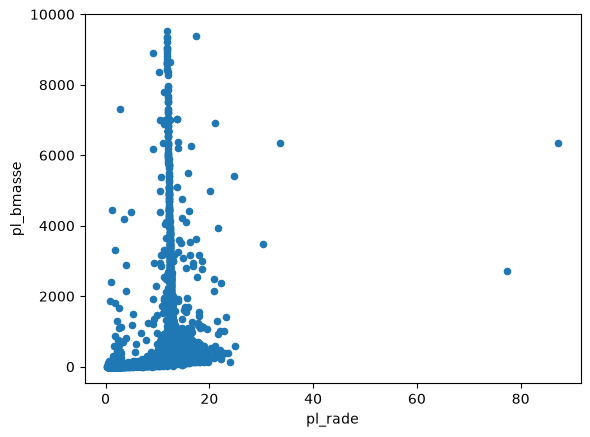

In [10]:
df.plot.scatter(
    x= "pl_rade",
    y="pl_bmasse"
)

<Axes: xlabel='pl_rade', ylabel='pl_bmasse'>

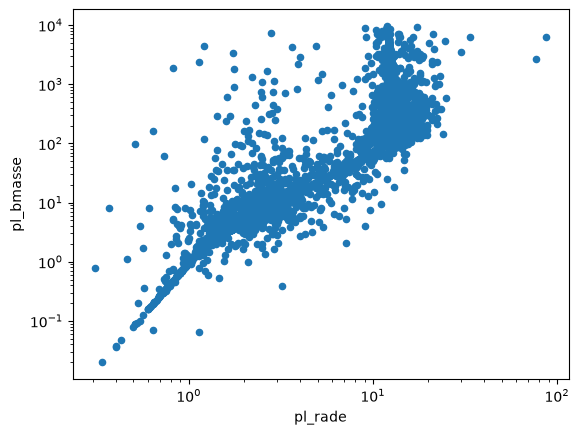

In [11]:
df.plot.scatter(
    x= "pl_rade",
    y="pl_bmasse",
    logx = True,
    logy = True
)

In [12]:
import numpy as np

df_log = df[["pl_rade","pl_bmasse"]].dropna().copy()

df_log["pl_rade"] = np.log10(df_log["pl_rade"])
df_log["pl_bmasse"] = np.log10(df_log["pl_bmasse"])
print(df_log.corr())

print(df_log.shape)

            pl_rade  pl_bmasse
pl_rade    1.000000   0.917287
pl_bmasse  0.917287   1.000000
(6280, 2)


<Axes: ylabel='Frequency'>

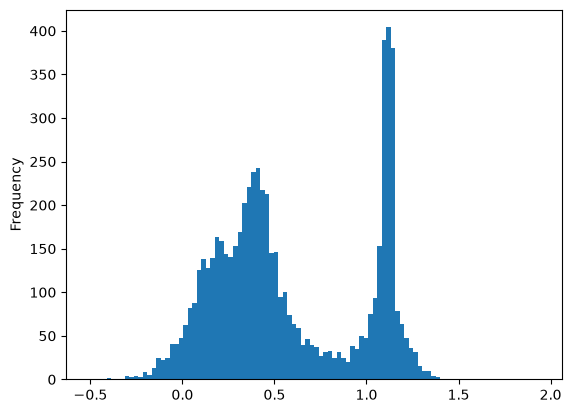

In [13]:
df_log["pl_rade"].dropna().plot.hist(bins=100)

<Axes: ylabel='Frequency'>

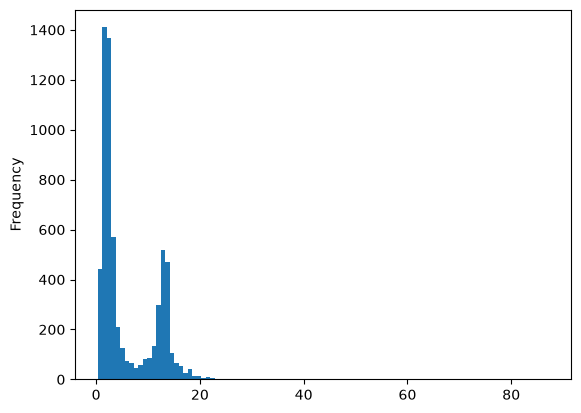

In [14]:
df["pl_rade"].dropna().plot.hist(bins=100)

In [15]:
#creamos una nueva caracteristicas que la llamaremos densidad relativa
#densidad del planeta respecto a la densida del planeta 
df["pl_density_rel"] = df["pl_bmasse"]/ (df["pl_rade"]**3)
print (df[["pl_name", "pl_rade","pl_density_rel"]].head(10))
print("="*50)
print(df)


         pl_name    pl_rade  pl_density_rel
0      HD 2039 b  12.700000        0.975965
1      KOI-142 b   3.438000        0.233779
2      HAT-P-8 b  15.692600        0.105274
3        K2-43 b   4.510000        0.201670
4  Kepler-1753 b   2.226781        0.506267
5  Kepler-1176 b   2.450000        0.446753
6       K2-126 b   1.970000        0.593823
7  Kepler-1263 b   1.140000        1.046206
8  Kepler-1416 b   0.880000        0.902458
9  Kepler-1542 c   0.650000        0.757396
            pl_name     hostname  discoverymethod  disc_year    pl_orbper  \
0         HD 2039 b      HD 2039  Radial Velocity       2002  1120.000000   
1         KOI-142 b      KOI-142          Transit       2013    10.916470   
2         HAT-P-8 b      HAT-P-8          Transit       2008     3.076340   
3           K2-43 b        K2-43          Transit       2016     3.471149   
4     Kepler-1753 b  Kepler-1753          Transit       2021    16.004601   
...             ...          ...              ...     

<Axes: ylabel='Frequency'>

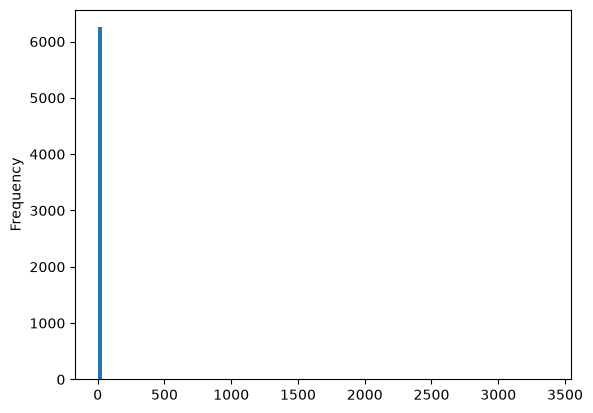

In [16]:
df_density = df.dropna(subset=["pl_name","pl_rade","pl_density_rel"])

df_density["pl_density_rel"].plot.hist(bins=100)

In [17]:
df[[
    "pl_name",
    "pl_rade",
    "pl_bmasse",
    "pl_density_rel"
]].sort_values(by="pl_density_rel",ascending=False).head(10)


,pl_name,pl_rade,pl_bmasse,pl_density_rel
2126,Kepler-32 f,0.820000,1862.110000,3377.254393
3443,Kepler-80 f,1.210000,4459.730000,2517.401320
5830,Kepler-324 b,1.140000,2414.400000,1629.651229
892,KOI-4777.01,0.510000,99.200000,747.827005
2354,Kepler-238 b,1.730000,3305.020000,638.316076
4066,K2-137 b,0.640000,158.915000,606.212616
5828,Kepler-245 e,1.750000,1806.360000,337.046764
1636,KOI-2513.01,2.802245,7310.053361,332.201936
1740,Kepler-37 e,0.370000,8.100000,159.911555
2361,Kepler-82 d,1.770000,885.098000,159.614213


<Axes: ylabel='Frequency'>

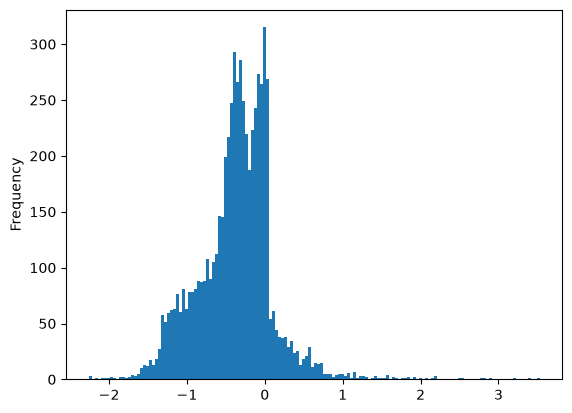

In [18]:
df_density["log_density_rel"]= np.log10(df_density["pl_density_rel"])
df_density["log_density_rel"].plot.hist(bins=150)

In [19]:
print(df_density["log_density_rel"].describe())
print(df_density["pl_density_rel"].describe())

count    6280.000000
mean       -0.367561
std         0.487082
min        -2.260668
25%        -0.619530
50%        -0.330847
75%        -0.075311
max         3.528564
Name: log_density_rel, dtype: float64
count    6280.000000
mean        2.619183
std        59.323843
min         0.005487
25%         0.240143
50%         0.466824
75%         0.840793
max      3377.254393
Name: pl_density_rel, dtype: float64


<Axes: xlabel='pl_rade', ylabel='pl_density_rel'>

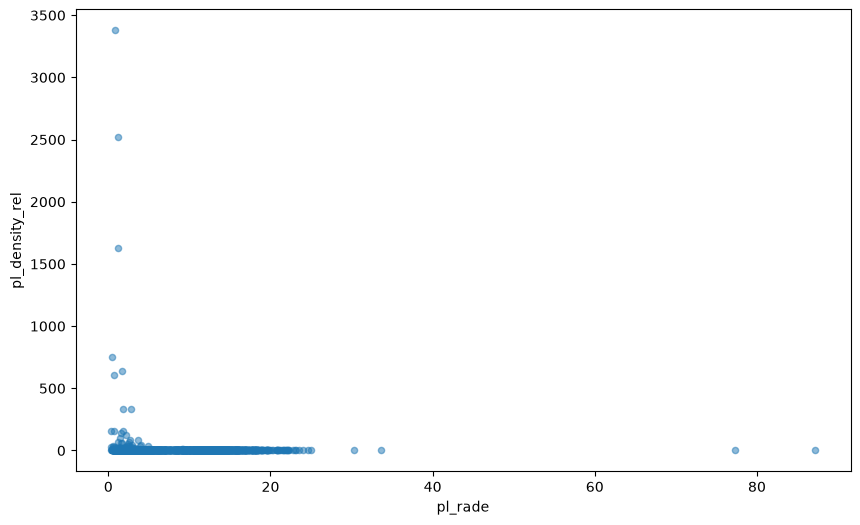

In [20]:
#como cambia la densida de un planeta cuando aumenta su radio?
#escala original
df_density.plot.scatter(
    x= "pl_rade",
    y= "pl_density_rel",
    figsize = (10,6),
    alpha = 0.5
    )


In [21]:
# La correlacion con el metodo Spearman nos ayuda a entender que si una variable aumenta la  otra la tambien debe aumentar incluso si no es lienal , a diferencia de spearso que busca la correlacion de marena lineal
#No existe una relacion lineal entre estas dos variables 
df_density[["pl_rade","pl_density_rel"]].corr(method="spearman")

# a medida que el radio tiende a subir, la densidad tiende a disminuir 

,pl_rade,pl_density_rel
pl_rade,1.000000,-0.643184
pl_density_rel,-0.643184,1.000000


In [22]:
# #crearemos una columna donde se dividiran los planetas en grupo de radios y calcularemos la mediaana

df_density["radio_group"] = pd.qcut(
     df_density["pl_rade"],
     q= 5
 )
df_density.groupby("radio_group").agg(
    mediana_density =("pl_density_rel", lambda x: x.median())

 )
# # En este conjunto de exoplanetas , lo planetas pertenecientes a grupos de mayor radio teienden a presentar menores valores de densidad relativa
# #Los resultados muestran una asociación negativa entre el radio planetario y la densidad relativa: los grupos con mayores radios presentan menores medianas de densidad. Este comportamiento es consistente con la relación matemática entre masa, volumen y densidad, aunque la densidad también depende de la masa, por lo que el aumento del radio por sí solo no implica necesariamente una disminución de la densidad.

,mediana_density
radio_group,
"(0.309, 1.64]",0.962052
"(1.64, 2.44]",0.571399
"(2.44, 3.72]",0.372340
"(3.72, 12.59]",0.197200
"(12.59, 87.206]",0.174336


<Axes: xlabel='pl_rade', ylabel='pl_density_rel'>

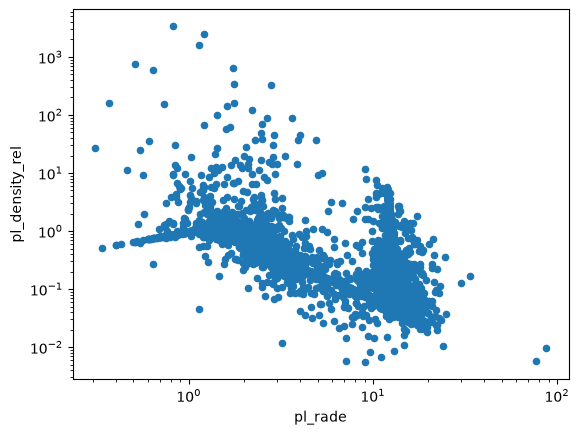

In [23]:
df_density.plot.scatter(
    x= "pl_rade",
    y="pl_density_rel",
    logx = True,
    logy = True
)
# Mayor radio → mayor masa, pero la masa no parece aumentar suficientemente rápido como para compensar el crecimiento del volumen.

In [24]:
df_density.groupby("radio_group").agg(
    mediana_masa = ("pl_bmasse","median"),
    medina_densidad = ("pl_density_rel","median")
)
#El aumento del radio está asociado con un aumento de la masa, pero la relación no es perfectamente proporcional.

,mediana_masa,medina_densidad
radio_group,,
"(0.309, 1.64]",2.290000,0.962052
"(1.64, 2.44]",5.100000,0.571399
"(2.44, 3.72]",8.780000,0.372340
"(3.72, 12.59]",70.600000,0.197200
"(12.59, 87.206]",476.742611,0.174336


In [25]:
from sklearn.linear_model import LinearRegression

x = df_log[["pl_rade"]] #m dataframe 2D
y = df_log["pl_bmasse"]

modelo = LinearRegression(n_jobs=-1)
modelo.fit(x,y)
y_predict = modelo.predict(x)
residuos = y -y_predict
print(modelo.coef_[0])
print(modelo.score(x,y))
print(residuos.describe())




2.375305611167319
0.8414150400331893
count    6.280000e+03
mean    -2.240246e-16
std      4.166012e-01
min     -1.695302e+00
25%     -1.875356e-01
50%     -6.268581e-02
75%      7.547664e-02
max      3.479201e+00
Name: pl_bmasse, dtype: float64


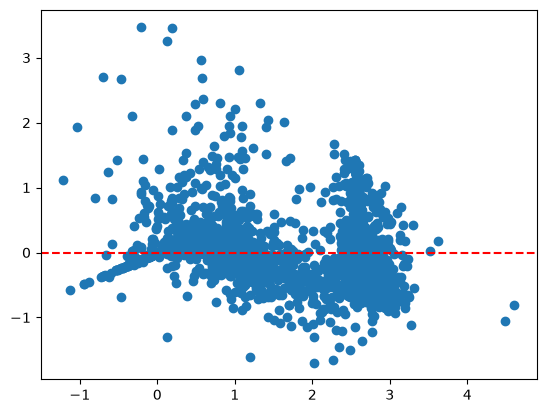

In [26]:
import matplotlib.pyplot as plt

plt.scatter(y_predict,residuos)
plt.axhline(0,color="r",linestyle="--")
plt.show()


# Periodo Orbital 

In [27]:
# Existe alguna relacion entre el tamaño de un planetea con su periodo orbital ?
print(df["pl_orbper"].describe())
print(df["pl_eqt"].describe())

count    6.009000e+03
mean     7.124358e+04
std      5.188337e+06
min      9.070629e-02
25%      4.305000e+00
50%      1.071253e+01
75%      3.857610e+01
max      4.020000e+08
Name: pl_orbper, dtype: float64
count    5825.000000
mean      835.177818
std       496.623847
min         1.480000
25%       486.000000
50%       756.000000
75%      1093.000000
max      7777.780000
Name: pl_eqt, dtype: float64


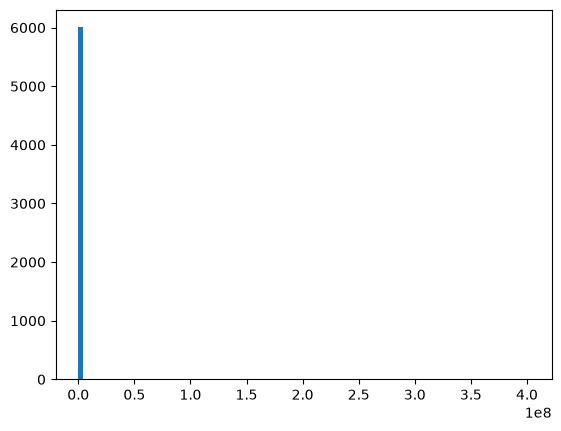

In [28]:
orbita =df["pl_orbper"].dropna()

plt.hist(orbita,bins=100,histtype="barstacked")
plt.show()

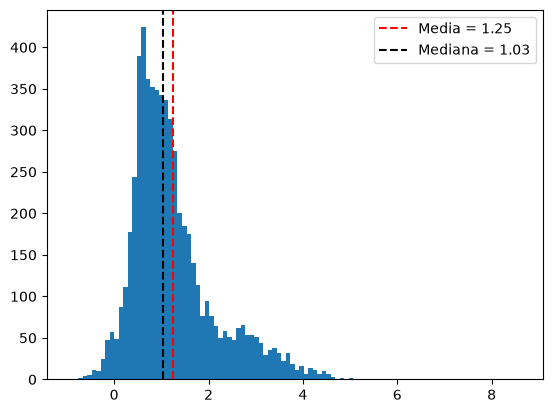

In [29]:
orbper_log = np.log10(
    df_density["pl_orbper"].dropna()
)
plt.hist(orbper_log,bins= 100,histtype="stepfilled")
plt.axvline(orbper_log.mean(),linestyle = "--", color = "r",label =f"Media = {orbper_log.mean():.2f}")
plt.axvline(orbper_log.median(),linestyle = "--", color = "black",label =f"Mediana = {orbper_log.median():.2f}")
plt.legend()
plt.show()

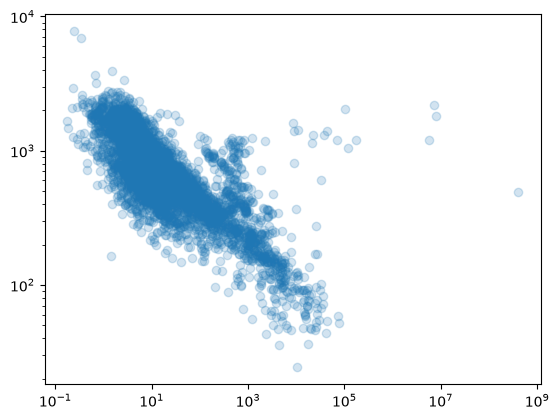

In [30]:
plt.scatter(df["pl_orbper"],
            df["pl_eqt"],
            alpha=0.2)
plt.xscale("log")
plt.yscale("log")
plt.show()

# Luminosidad de una estrella 
$$
L \propto st\_rad^2 \times st\_teff^4
$$
## radiacion recibida 
$$
∝a^2/L​
$$
## semieje mayor de la orbita 
$$
a = (M * P^2)^1/3
$$
donde:

\(P\) = período orbital\
\(a\) = semieje mayor de la órbita, que usamos como aproximación de la distancia orbital

In [31]:
df_eqt = df[["pl_eqt","pl_orbper","st_teff","st_rad","st_mass"]].dropna().copy()
df_eqt["luminosity"] = (df_eqt["st_rad"]**2) * (df_eqt["st_teff"]**4)
df_eqt


,pl_eqt,pl_orbper,st_teff,st_rad,st_mass,luminosity
0,210.84,1120.000000,5945.00,1.190000,1.230000,1.768892e+15
1,758.00,10.916470,5466.00,0.897000,0.990000,7.182298e+14
2,1713.00,3.076340,6200.00,1.570000,1.270000,3.642219e+15
3,939.30,3.471149,3840.60,0.542000,0.571000,6.391384e+13
4,583.00,16.004601,5180.00,0.769000,0.860000,4.257667e+14
...,...,...,...,...,...,...
6348,586.00,9.034199,4632.00,0.666000,0.729000,2.041844e+14
6349,835.00,11.094286,6043.00,1.014000,1.006000,1.371154e+15
6350,1063.00,4.243747,5735.00,0.950000,0.980000,9.762946e+14
6351,979.00,2.399964,4402.71,0.619575,0.701968,1.442341e+14


In [32]:
df_eqt.corr(method="spearman")

,pl_eqt,pl_orbper,st_teff,st_rad,st_mass,luminosity
pl_eqt,1.000000,-0.785045,0.372724,0.322308,0.335176,0.328593
pl_orbper,-0.785045,1.000000,0.037957,0.194803,0.155929,0.194942
st_teff,0.372724,0.037957,1.000000,0.739011,0.788249,0.790329
st_rad,0.322308,0.194803,0.739011,1.000000,0.933345,0.983826
st_mass,0.335176,0.155929,0.788249,0.933345,1.000000,0.941932
luminosity,0.328593,0.194942,0.790329,0.983826,0.941932,1.000000
